In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
from matplotlib.colors import TwoSlopeNorm

In [2]:
# Load data
anomaly_path = "1month_anomaly_Global_ea_tp_202602_1991-2020_v02.grib"
climatology_path = "climatology_0.25g_ea_tp_02_1991-2020_v02.grib"

anomaly = xr.open_dataset(anomaly_path, engine="cfgrib")
climatology = xr.open_dataset(climatology_path, engine="cfgrib")

In [3]:
anomaly

<xarray.Dataset> Size: 4MB
Dimensions:     (latitude: 721, longitude: 1440)
Coordinates:
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number      int64 8B ...
    time        datetime64[ns] 8B ...
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
    valid_time  datetime64[ns] 8B ...
Data variables:
    tp          (latitude, longitude) float32 4MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-07-06T18:10 GRIB to CDM+CF via cfgrib-0.9.1...

In [4]:
# Stats (anomaly)
print("min tp:", anomaly["tp"].min().item())
print("max tp:", anomaly["tp"].max().item())
print("count:", anomaly["tp"].count().item())
print("missing values:", anomaly["tp"].isnull().sum().item()) 

min tp: -0.020128250122070312
max tp: 0.031394004821777344
count: 1038240
missing values: 0


In [5]:
climatology

<xarray.Dataset> Size: 4MB
Dimensions:     (latitude: 721, longitude: 1440)
Coordinates:
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number      int64 8B ...
    time        datetime64[ns] 8B ...
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
    valid_time  datetime64[ns] 8B ...
Data variables:
    tp          (latitude, longitude) float32 4MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-07-06T18:10 GRIB to CDM+CF via cfgrib-0.9.1...

In [6]:
# Stats (climatology)
print("min tp:", climatology["tp"].min().item())
print("max tp:", climatology["tp"].max().item())
print("count:", climatology["tp"].count().item())
print("missing values:", climatology["tp"].isnull().sum().item())  

min tp: 0.0
max tp: 0.06138896942138672
count: 1038240
missing values: 0


In [7]:
# Convert m to mm
anomaly_mm = anomaly["tp"] * 1000
climatology_mm = climatology["tp"] * 1000

In [8]:
# Percent of normal precipitation
percent_of_normal = ((climatology_mm + anomaly_mm) / climatology_mm) * 100

In [9]:
# Convert longitude coords from 0-359 to -180-179
def adjust_longitude(ds):
    return ds.assign_coords(
        longitude=((ds.longitude + 180) % 360) - 180
    ).sortby("longitude")

anomaly = adjust_longitude(anomaly)
climatology = adjust_longitude(climatology)
percent_of_normal = adjust_longitude(percent_of_normal.to_dataset(name="p"))["p"]

In [10]:
# Crop Europe
lon_min, lon_max = -20, 45
lat_min, lat_max = 34, 66

percent_of_normal_cropped = percent_of_normal.sel(
    latitude=slice(lat_max, lat_min),
    longitude=slice(lon_min, lon_max)
)

In [11]:
title = """
    Rainfall in mainland Portugal in February 2026
    was four times higher than the 1991–2020 average
    """
source = """
    Data: Copernicus Climate Change Service (C3S) Climate Data Store (CDS), DOI: 10.24381/7470b643
    Created by: Bernadett Piros
    """

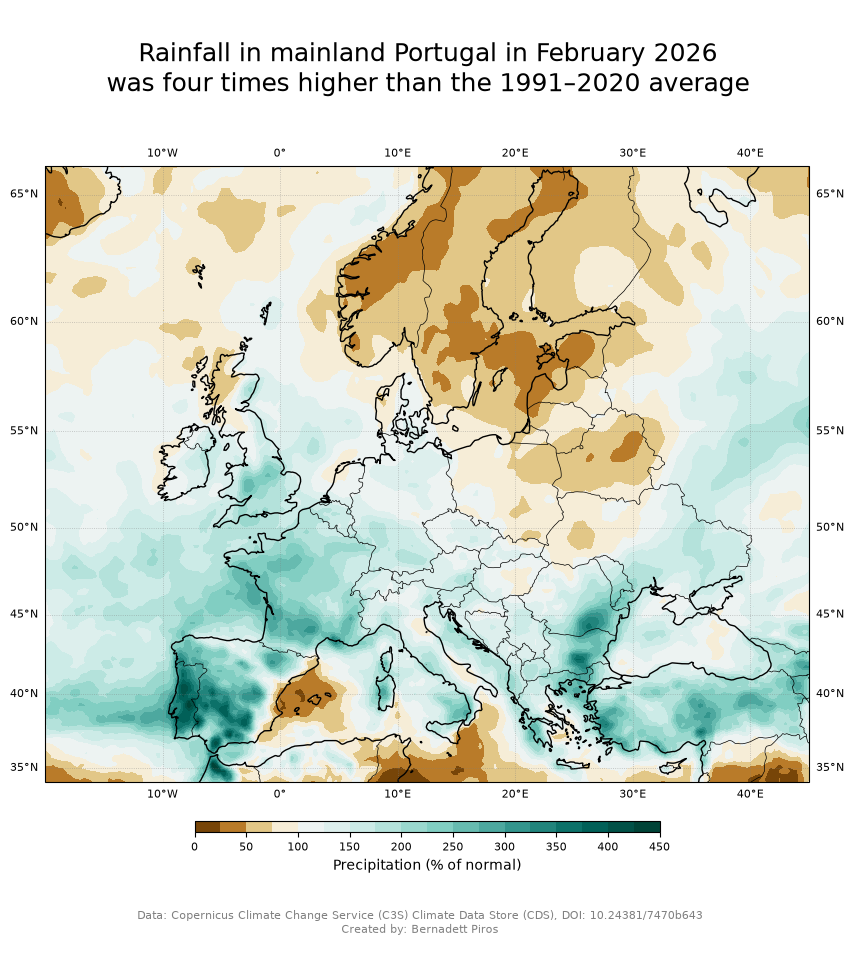

In [12]:
fig, ax = plt.subplots(figsize=(12, 10),  subplot_kw={"projection": ccrs.Mercator()})

gl = ax.gridlines(draw_labels=True, linewidth=.6, color='gray', alpha=0.5, linestyle='dotted')
gl.xlabel_style = {"size" : 8}
gl.ylabel_style = {"size" : 8}

norm = TwoSlopeNorm(
    vmin=0,
    vcenter=100,
    vmax=450
)

mesh = ax.contourf(
    percent_of_normal_cropped.longitude,
    percent_of_normal_cropped.latitude,
    percent_of_normal_cropped,
    cmap="BrBG",
    transform=ccrs.PlateCarree(),
    levels=20,
    norm=norm,
    )

ax.coastlines(resolution="50m")
ax.add_feature(cf.BORDERS, linewidth=0.5)

ax.set_extent(
    [lon_min, lon_max, lat_min, lat_max],
    crs=ccrs.PlateCarree(),
    )

cbar = plt.colorbar(mesh, orientation="horizontal", shrink=0.5, aspect=40, pad=0.05)
cbar.set_label("Precipitation (% of normal)")
cbar.ax.tick_params(labelsize=8)

fig.text(0.5, 0.925, s=title, size=18, ha="center")

fig.text(0.5, 0.1, s=source, color="grey", size=8, ha="center")
plt.show()

# Save figure
#fig.savefig("Rainfall Feb 2026.png", bbox_inches="tight", pad_inches=0.2)